# Support Vector Machine (SVM) for Handwritten Digit Classification

## Objective
The objective of this experiment is to classify handwritten digits using the Support Vector Machine (SVM) algorithm.

We will:
- Load the handwritten digits dataset.
- Select the first 1000 samples.
- Train SVM using Linear Kernel.
- Train SVM using RBF Kernel.
- Compare accuracy and training time.
- Plot a confusion matrix.
- Visualize the decision boundary for a 2-class subset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

In [ ]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset Shape:", X.shape)

Dataset Shape: (1797, 64)


In [ ]:
X = X[:1000]
y = y[:1000]

print("New Shape:", X.shape)

New Shape: (1000, 64)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


Train SVM Using Linear Kernel

Linear Kernel creates a straight decision boundary.
Training time will also be measured.

In [ ]:
start = time.time()

linear_svm = SVC(kernel='linear')

linear_svm.fit(X_train, y_train)

linear_time = time.time() - start

print("Linear Kernel Training Time:",
    round(linear_time,4),"seconds")

Linear Kernel Training Time: 0.0452 seconds


Test Linear Kernel Model

In [ ]:
linear_predictions = linear_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test,linear_predictions)

print("Linear Kernel Accuracy:",round(linear_accuracy*100,2),"%")

Linear Kernel Accuracy: 98.5 %


Train SVM Using RBF Kernel

RBF (Radial Basis Function) can handle non-linear data.

In [ ]:
start = time.time()

rbf_svm = SVC(kernel='rbf')

rbf_svm.fit(X_train, y_train)

rbf_time = time.time() - start

print("RBF Kernel Training Time:",round(rbf_time,4),"seconds")

RBF Kernel Training Time: 0.0523 seconds


Test RBF Kernel Model

In [ ]:
rbf_predictions = rbf_svm.predict(X_test)

rbf_accuracy = accuracy_score(y_test,rbf_predictions)

print("RBF Kernel Accuracy:",round(rbf_accuracy*100,2),"%")

RBF Kernel Accuracy: 99.5 %


 Compare Linear Kernel and RBF Kernel

In [ ]:
print(" Comparison:")

print("Linear Accuracy:",round(linear_accuracy*100,2),"%")

print("RBF Accuracy:",round(rbf_accuracy*100,2),"%")

print("Linear Training Time:",round(linear_time,4),"sec")

print("RBF Training Time:",round(rbf_time,4),"sec")

 Comparison:
Linear Accuracy: 98.5 %
RBF Accuracy: 99.5 %
Linear Training Time: 0.0452 sec
RBF Training Time: 0.0523 sec


In [ ]:
print(classification_report(
    y_test,
    rbf_predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.97        18
           5       1.00      0.96      0.98        23
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        17
           8       1.00      1.00      1.00        19
           9       1.00      1.00      1.00        20

    accuracy                           0.99       200
   macro avg       0.99      1.00      1.00       200
weighted avg       1.00      0.99      1.00       200



In [ ]:
cm = confusion_matrix(
    y_test,
    rbf_predictions
)


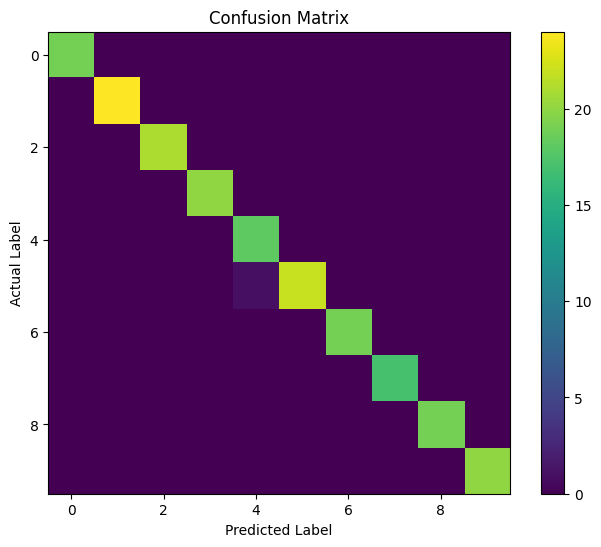

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Select Only Digits 0 and 1

Decision boundaries can only be visualized properly in a two-class problem.

In [ ]:
mask = (y == 0) | (y == 1)

X_binary = X[mask]
y_binary = y[mask]

print(X_binary.shape)

(201, 64)


Apply PCA

The original dataset has 64 features.

PCA reduces it to 2 dimensions so that we can visualize the decision boundary.

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_binary)

print(X_pca.shape)

(201, 2)


 Train SVM on PCA Data

In [ ]:
svm_2d = SVC(kernel='rbf')

svm_2d.fit(X_pca, y_binary)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Mesh Grid for Decision Boundary

In [ ]:
h = 0.02

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Predict Mesh Grid Points

In [ ]:
Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

Plot Decision Boundary

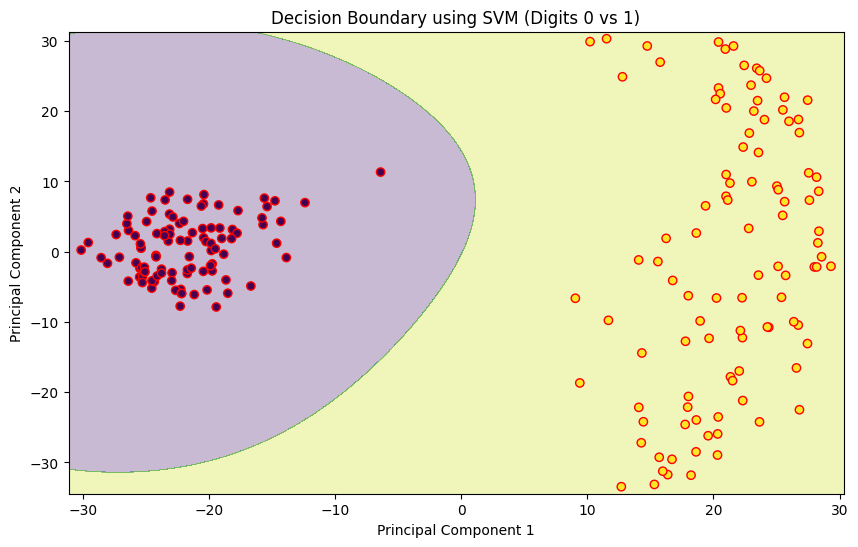

In [ ]:
plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_binary,
    edgecolors='r'
)

plt.title("Decision Boundary using SVM (Digits 0 vs 1)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# Conclusion

The Support Vector Machine (SVM) algorithm was applied to classify handwritten digits.

Two kernels were compared:

1. Linear Kernel
2. RBF Kernel

The RBF kernel generally achieved better accuracy because it can handle non-linear relationships. Training time was also measured, showing that SVM becomes slower as dataset size increases.

The decision boundary plot demonstrated how SVM separates two classes using a maximum-margin hyperplane.